In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from multiprocessing import cpu_count

# プロジェクトルートをパスに追加
current_dir = os.path.dirname(os.path.abspath('.'))
sys.path.append(current_dir)
sys.path.append(os.path.abspath(os.path.join(current_dir, "..")))


from simulation.hawkes import HawkesParams, kernel, thinning_rate, lamb_i
from simulation.network import ER, Network

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [2]:
event_data = np.load(os.path.join(current_dir, "workers", "hawkes_worker_00.npz"), allow_pickle=True)

event_times = event_data["event_times_all"]
event_nodes = event_data["event_nodes_all"]

print(f"event_times.shape: {event_times.shape}")
print(f"event_nodes.shape: {event_nodes.shape}")

print(f"event_times[0, 0]: {event_times[0, 0]}")
print(f"event_nodes[0, 0]: {event_nodes[0, 0]}")


event_times.shape: (30, 100)
event_nodes.shape: (30, 100)
event_times[0, 0]: [0]
event_nodes[0, 0]: [3033]


In [7]:
cur_event_data = np.load(os.path.join(current_dir, "workers", f"hawkes_worker_00.npz"), allow_pickle=True)
print(f"cur_event_data.shape: {cur_event_data["event_nodes_all"].shape}")
print(f"cur_event_data.shape: {cur_event_data["event_times_all"].shape}")
print(f"cur_event_data.shape: {cur_event_data["event_times_all"][:, 2]}")

cur_event_data.shape: (30, 100)
cur_event_data.shape: (30, 100)
cur_event_data.shape: [array([0.        , 1.00642559, 1.18104421]) array([0]) array([0])
 array([0]) array([0]) array([0]) array([0]) array([0]) array([0])
 array([0]) array([0]) array([0]) array([0]) array([0]) array([0])
 array([0]) array([0]) array([0]) array([0]) array([0]) array([0])
 array([0]) array([0]) array([0]) array([0]) array([0]) array([0])
 array([0]) array([0]) array([0])]


In [8]:
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
load_worker_num = 6 

len_args = event_data["event_times_all"].shape[1]
repeats = event_data["event_times_all"].shape[0]

shape = (len_args, repeats * load_worker_num)
event_nums = np.zeros(shape, dtype=np.ndarray)

for i in range(len_args):
    if i % 10 ==0 or i == len_args-1:
        print(f"i: {i}")
    for worker_id in range(load_worker_num):
        for repeat_idx in range(repeats):
            cur_event_data = np.load(os.path.join(current_dir, "workers", f"hawkes_worker_{worker_id:02d}.npz"), allow_pickle=True)
            event_nums[i, worker_id * repeats + repeat_idx] = len(cur_event_data["event_nodes_all"][repeat_idx, i])

print(event_nums.shape)
print(event_nums)

i: 0
i: 10
i: 20
i: 30
i: 40
i: 50
i: 60
i: 70
i: 80
i: 90
i: 99
(100, 180)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [3 1 1 ... 1 1 1]
 ...
 [100001 1 1 ... 100001 2 100001]
 [1 1 100001 ... 100001 100001 1]
 [1 1 1 ... 100001 1 1]]


(array([1.4752e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 3.2470e+03]),
 array([1.00000e+00, 1.00010e+04, 2.00010e+04, 3.00010e+04, 4.00010e+04,
        5.00010e+04, 6.00010e+04, 7.00010e+04, 8.00010e+04, 9.00010e+04,
        1.00001e+05]),
 <BarContainer object of 10 artists>)

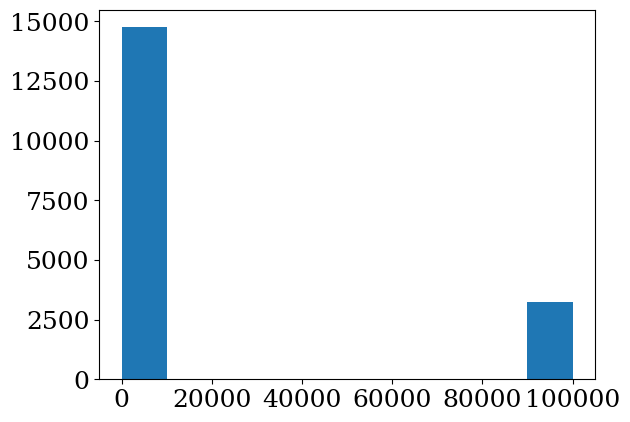

In [9]:
plt.hist(event_nums.flatten())

(array([174.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   6.]),
 array([1.00000e+00, 1.00010e+04, 2.00010e+04, 3.00010e+04, 4.00010e+04,
        5.00010e+04, 6.00010e+04, 7.00010e+04, 8.00010e+04, 9.00010e+04,
        1.00001e+05]),
 <BarContainer object of 10 artists>)

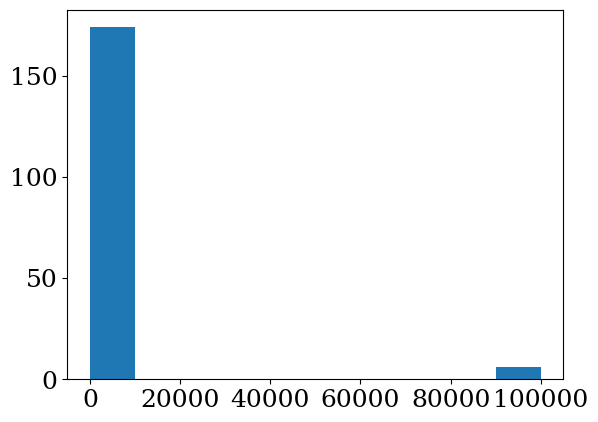

In [11]:
plt.hist(event_nums[20])

In [12]:
np.savez("event_nums.npz", event_nums=event_nums)

In [9]:
import numpy as np

data = np.load("event_nums.npz", allow_pickle=True)

In [10]:
data

NpzFile 'event_nums.npz' with keys: event_nums

In [11]:
event_nums = data['event_nums']
print(event_nums.shape)

(100, 180)


In [13]:
na = 100
a_values = np.linspace(0.0001, 0.05, na)

(array([126.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  54.]),
 array([1.00000e+00, 1.00010e+04, 2.00010e+04, 3.00010e+04, 4.00010e+04,
        5.00010e+04, 6.00010e+04, 7.00010e+04, 8.00010e+04, 9.00010e+04,
        1.00001e+05]),
 <BarContainer object of 10 artists>)

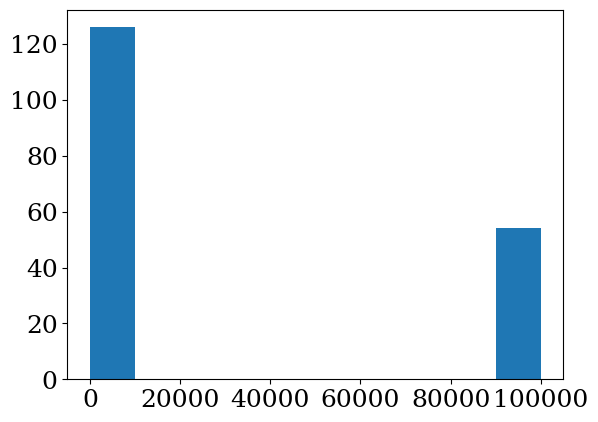

In [15]:
plt.hist(event_nums[90])